# Student Dropout Prediction

## Contents
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Model Training — LR, DT, NN
4. Model Performance Comparison
5. Applying the Best Model on New Data
6. Clustering — K-Means
7. Conclusion

## 1. Exploratory Data Analysis (EDA)

The dataset comes from the **Open University Learning Analytics (OULA)** dataset. It contains information about students, their interactions with the Virtual Learning Environment (VLE), assessments, and final outcomes.

**Tables:**
- `courses` – module and presentation info
- `assessments` – assessment metadata (type, date, weight)
- `studentInfo` – demographics and final result (Pass / Fail / Withdrawn / Distinction)
- `studentAssessment` – student scores on assessments
- `studentRegistration` – registration and unregistration dates
- `studentVle` – student interactions (clicks) with VLE resources
- `vle` – VLE resource metadata

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Suppress warnings globally (including in child processes spawned by joblib)
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load all datasets
courses = pd.read_csv('data/courses.csv')
assessments = pd.read_csv('data/assessments.csv')
student_info = pd.read_csv('data/studentInfo.csv')
student_assessment = pd.read_csv('data/studentAssessment.csv')
student_registration = pd.read_csv('data/studentRegistration.csv')
student_vle = pd.read_csv('data/studentVle.csv')
vle = pd.read_csv('data/vle.csv')

datasets = {
    'courses': courses,
    'assessments': assessments,
    'student_info': student_info,
    'student_assessment': student_assessment,
    'student_registration': student_registration,
    'student_vle': student_vle,
    'vle': vle
}

# Overview of all tables
for name, df in datasets.items():
    print(f"{'='*50}")
    print(f"  {name}: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"{'='*50}")
    print(f"Columns: {list(df.columns)}")
    print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Dtypes:\n{df.dtypes}\n")

  courses: 22 rows × 3 columns
Columns: ['code_module', 'code_presentation', 'module_presentation_length']
Missing values:
Series([], dtype: int64)
Dtypes:
code_module                     str
code_presentation               str
module_presentation_length    int64
dtype: object

  assessments: 206 rows × 6 columns
Columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
Missing values:
date    11
dtype: int64
Dtypes:
code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

  student_info: 32593 rows × 12 columns
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
Missing values:
imd_band    1111
dtype: int64
Dtypes:
code_module               str
code_presentation         

### 1.1 Student Demographics & Final Results

The `studentInfo` table is the central table — it contains student demographics and the **target variable** (`final_result`): Pass, Fail, Withdrawn, or Distinction.

In [3]:
# Quick look at studentInfo
print(f"Shape: {student_info.shape}")
student_info.head(10)

Shape: (32593, 12)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,N,Pass
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,N,Pass
8,AAA,2013J,52130,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,N,Pass
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,NaN,55<=,0,60,N,Pass


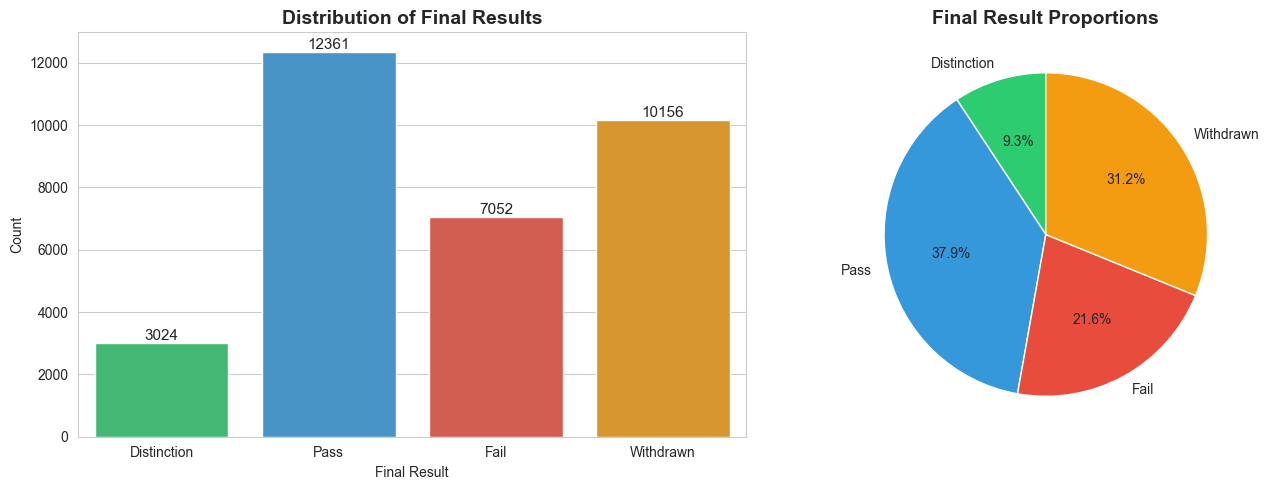


Total student-module registrations: 32593
Unique students: 28785

Final result distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [4]:
# Distribution of the target variable: final_result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
sns.countplot(data=student_info, x='final_result', order=order, palette=colors, ax=axes[0])
axes[0].set_title('Distribution of Final Results', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
counts = student_info['final_result'].value_counts().reindex(order)
axes[1].pie(counts, labels=order, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Final Result Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal student-module registrations: {len(student_info)}")
print(f"Unique students: {student_info['id_student'].nunique()}")
print(f"\nFinal result distribution:\n{student_info['final_result'].value_counts()}")

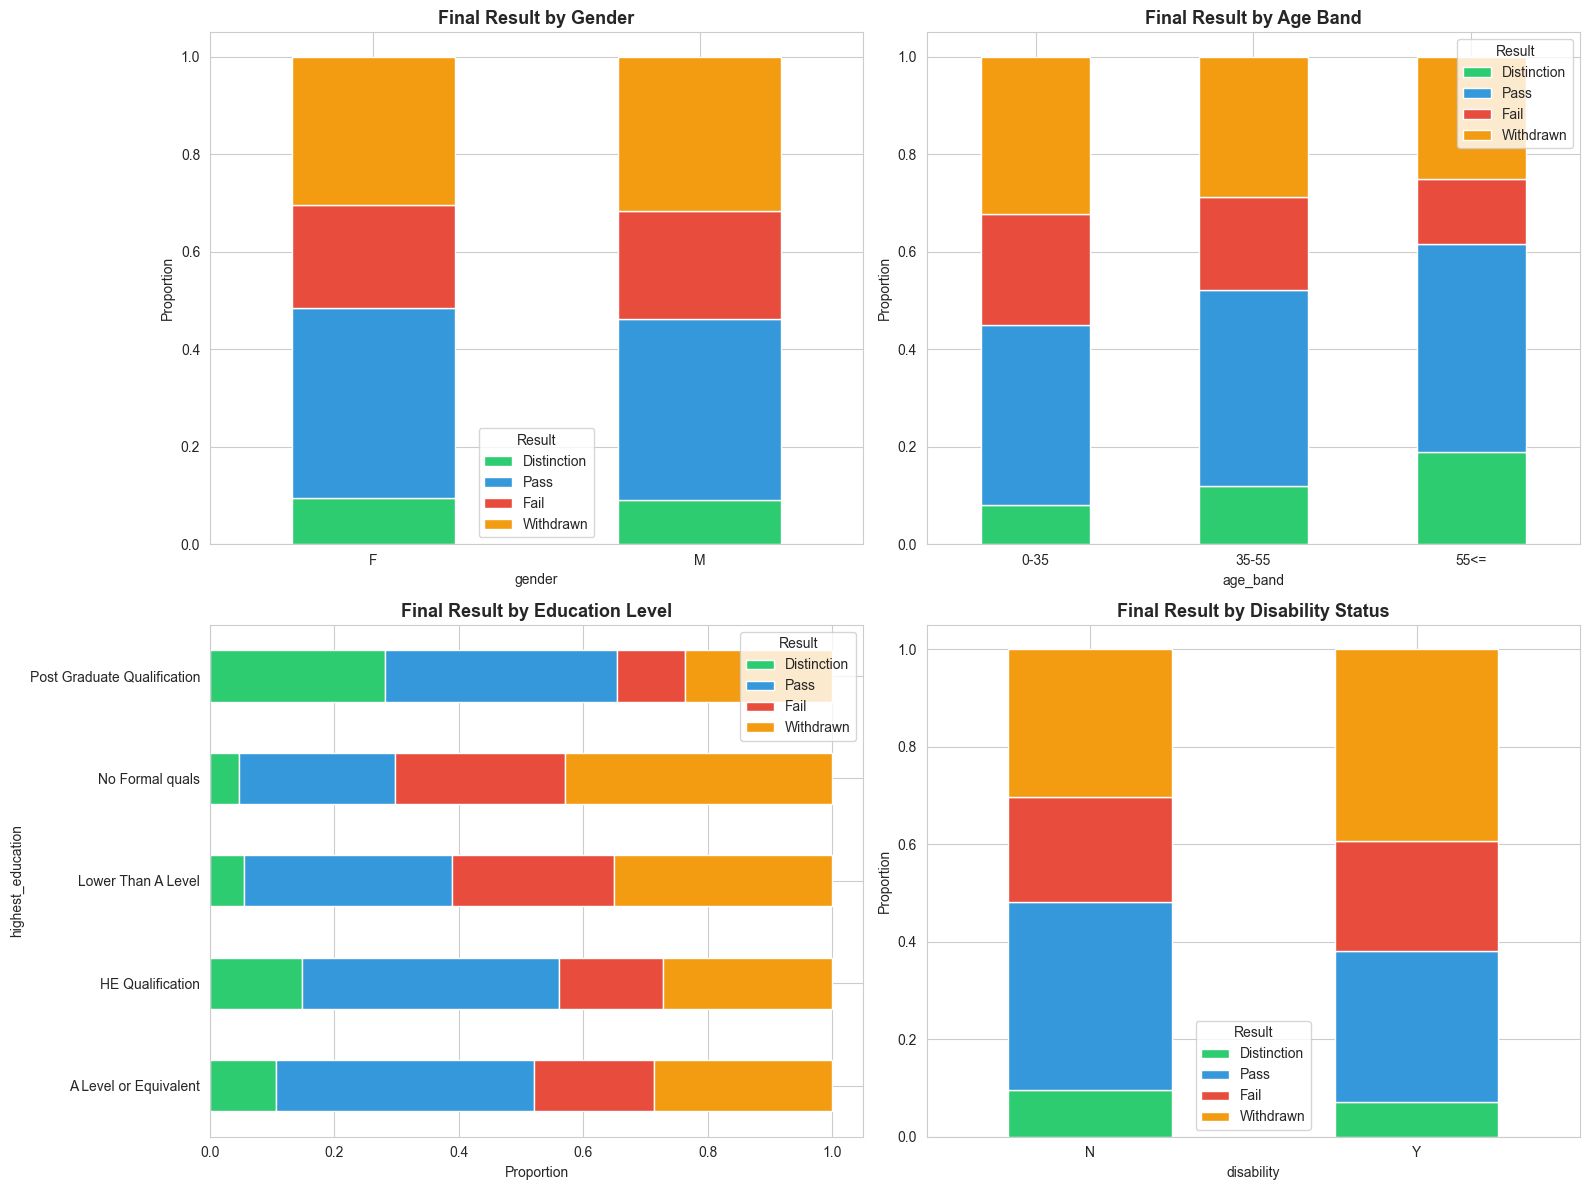

In [5]:
# Demographics breakdown by final result
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender vs Final Result
ct_gender = pd.crosstab(student_info['gender'], student_info['final_result'], normalize='index')[order]
ct_gender.plot(kind='bar', stacked=True, color=colors, ax=axes[0, 0])
axes[0, 0].set_title('Final Result by Gender', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].legend(title='Result')
axes[0, 0].tick_params(axis='x', rotation=0)

# Age Band vs Final Result
ct_age = pd.crosstab(student_info['age_band'], student_info['final_result'], normalize='index')[order]
ct_age.plot(kind='bar', stacked=True, color=colors, ax=axes[0, 1])
axes[0, 1].set_title('Final Result by Age Band', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].legend(title='Result')
axes[0, 1].tick_params(axis='x', rotation=0)

# Highest Education vs Final Result
ct_edu = pd.crosstab(student_info['highest_education'], student_info['final_result'], normalize='index')[order]
ct_edu.plot(kind='barh', stacked=True, color=colors, ax=axes[1, 0])
axes[1, 0].set_title('Final Result by Education Level', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Proportion')
axes[1, 0].legend(title='Result')

# Disability vs Final Result
ct_dis = pd.crosstab(student_info['disability'], student_info['final_result'], normalize='index')[order]
ct_dis.plot(kind='bar', stacked=True, color=colors, ax=axes[1, 1])
axes[1, 1].set_title('Final Result by Disability Status', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].legend(title='Result')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 1.2 Courses & Assessments

Courses:
code_module code_presentation  module_presentation_length
        AAA             2013J                         268
        AAA             2014J                         269
        BBB             2013J                         268
        BBB             2014J                         262
        BBB             2013B                         240
        BBB             2014B                         234
        CCC             2014J                         269
        CCC             2014B                         241
        DDD             2013J                         261
        DDD             2014J                         262
        DDD             2013B                         240
        DDD             2014B                         241
        EEE             2013J                         268
        EEE             2014J                         269
        EEE             2014B                         241
        FFF             2013J                         268
     

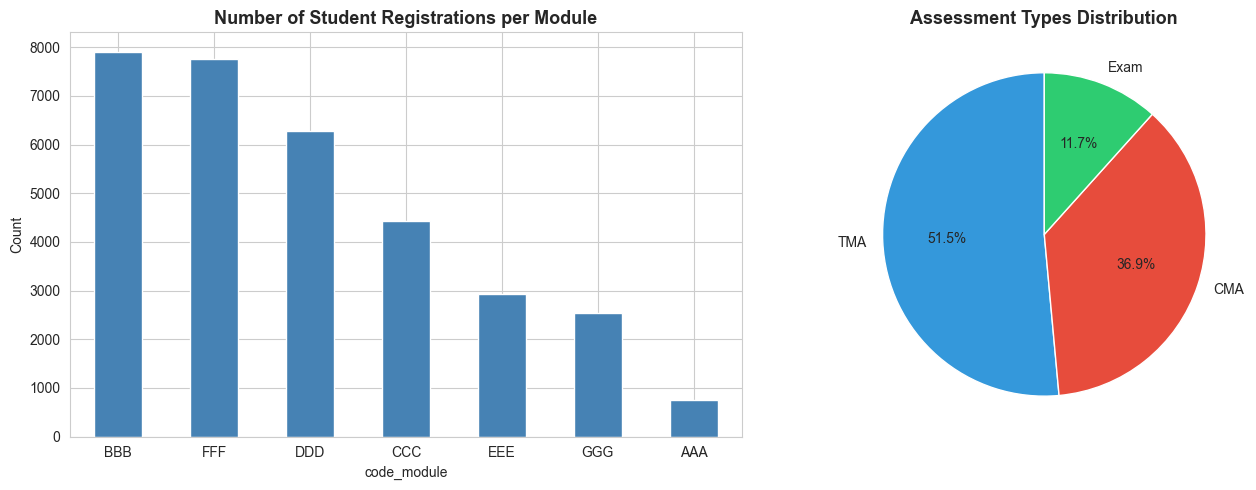

In [6]:
# Courses overview
print("Courses:")
print(courses.to_string(index=False))
print(f"\nModules: {courses['code_module'].unique()}")
print(f"Presentations: {courses['code_presentation'].unique()}")

# Students per module
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

students_per_module = student_info.groupby('code_module')['id_student'].count().sort_values(ascending=False)
students_per_module.plot(kind='bar', color='steelblue', ax=axes[0])
axes[0].set_title('Number of Student Registrations per Module', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Assessment types distribution
assessment_types = assessments['assessment_type'].value_counts()
axes[1].pie(assessment_types, labels=assessment_types.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Assessment Types Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.3 Student Assessment Scores

Student Assessment records: 173912

Score statistics:
count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64


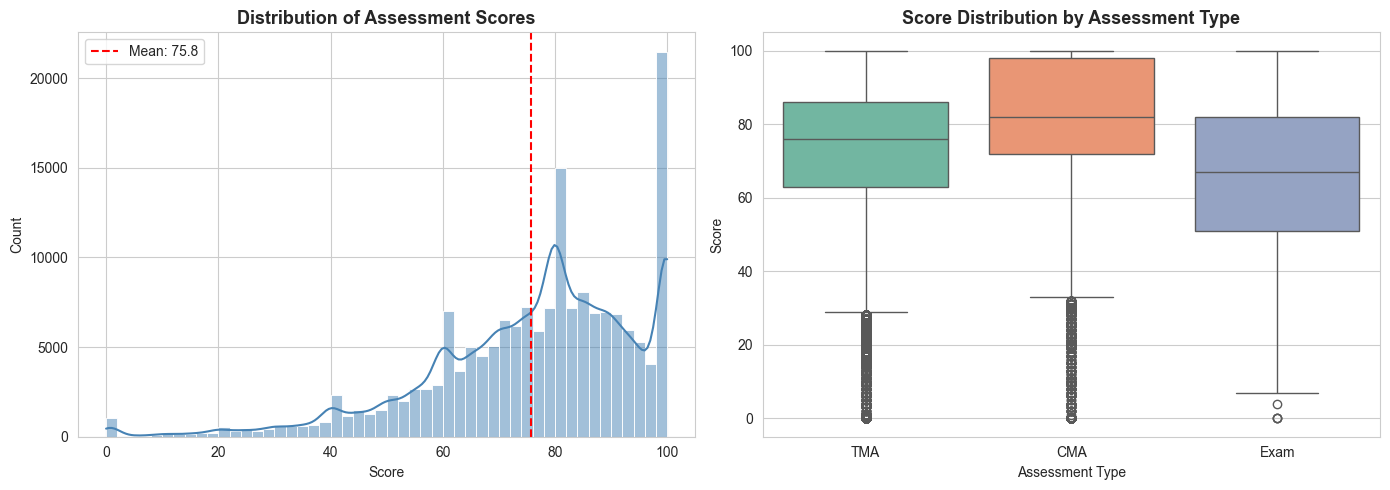

In [7]:
# Merge student assessments with student info to see scores by final result
sa_merged = student_assessment.merge(
    assessments[['id_assessment', 'assessment_type', 'weight']],
    on='id_assessment', how='left'
)

print(f"Student Assessment records: {len(sa_merged)}")
print(f"\nScore statistics:\n{sa_merged['score'].describe()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
sns.histplot(sa_merged['score'].dropna(), bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Assessment Scores', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].axvline(sa_merged['score'].mean(), color='red', linestyle='--', label=f"Mean: {sa_merged['score'].mean():.1f}")
axes[0].legend()

# Score by assessment type
sns.boxplot(data=sa_merged, x='assessment_type', y='score', palette='Set2', ax=axes[1])
axes[1].set_title('Score Distribution by Assessment Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Assessment Type')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

### 1.4 VLE Engagement (Student Clicks)

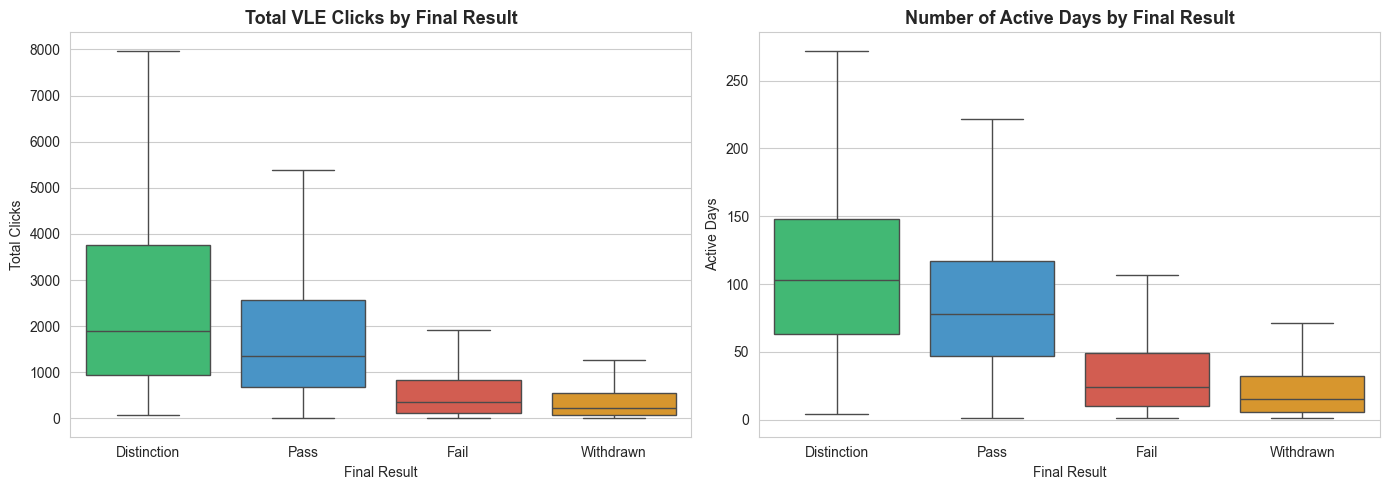

Median total clicks by result:
final_result
Distinction    1896.0
Pass           1343.0
Fail            353.0
Withdrawn       221.5
Name: total_clicks, dtype: float64

Median active days by result:
final_result
Distinction    103.0
Pass            78.0
Fail            24.0
Withdrawn       15.0
Name: num_days_active, dtype: float64


In [8]:
# Total VLE clicks per student (aggregated across all modules)
vle_per_student = student_vle.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    total_clicks=('sum_click', 'sum'),
    num_days_active=('date', 'nunique')
).reset_index()

# Merge with final result
vle_with_result = vle_per_student.merge(
    student_info[['code_module', 'code_presentation', 'id_student', 'final_result']],
    on=['code_module', 'code_presentation', 'id_student'], how='inner'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total clicks by final result
sns.boxplot(data=vle_with_result, x='final_result', y='total_clicks', order=order, palette=colors, ax=axes[0],
            showfliers=False)
axes[0].set_title('Total VLE Clicks by Final Result', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Total Clicks')

# Active days by final result
sns.boxplot(data=vle_with_result, x='final_result', y='num_days_active', order=order, palette=colors, ax=axes[1],
            showfliers=False)
axes[1].set_title('Number of Active Days by Final Result', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Final Result')
axes[1].set_ylabel('Active Days')

plt.tight_layout()
plt.show()

# Print median values
print("Median total clicks by result:")
print(vle_with_result.groupby('final_result')['total_clicks'].median().reindex(order))
print("\nMedian active days by result:")
print(vle_with_result.groupby('final_result')['num_days_active'].median().reindex(order))

### 1.5 Registration Timing & Withdrawals

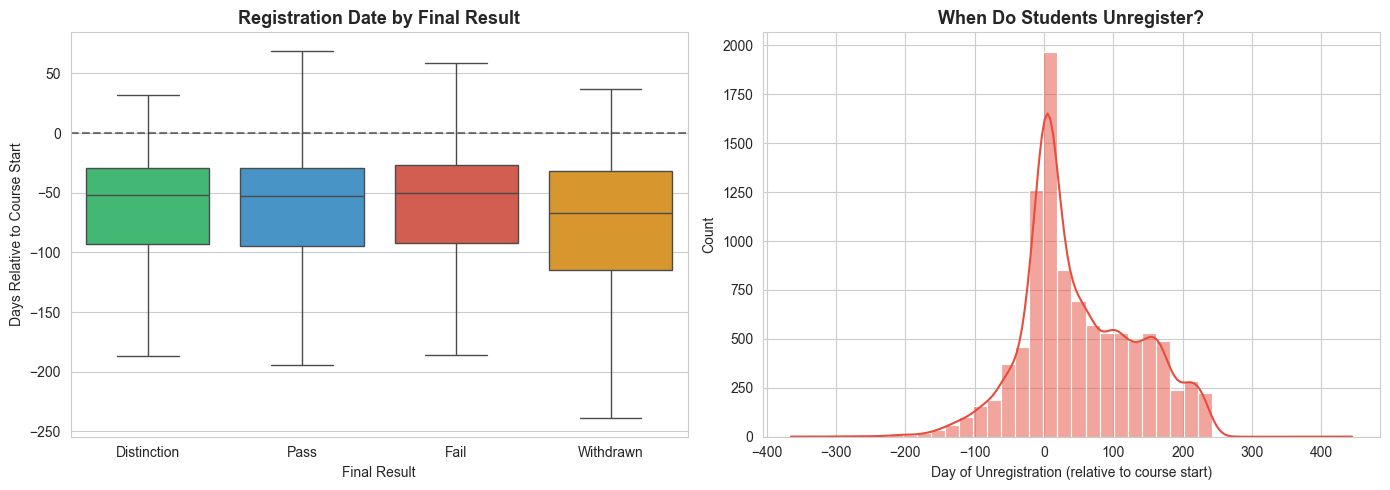

Students with unregistration date: 10072 (30.9%)


In [9]:
# Registration timing analysis
reg_with_result = student_registration.merge(
    student_info[['code_module', 'code_presentation', 'id_student', 'final_result']],
    on=['code_module', 'code_presentation', 'id_student'], how='inner'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Registration date by final result (negative = registered before course start)
sns.boxplot(data=reg_with_result, x='final_result', y='date_registration', order=order,
            palette=colors, ax=axes[0], showfliers=False)
axes[0].set_title('Registration Date by Final Result', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Days Relative to Course Start')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)

# Unregistration date distribution for withdrawn students
withdrawn_unreg = reg_with_result[reg_with_result['date_unregistration'].notna()]
sns.histplot(withdrawn_unreg['date_unregistration'], bins=40, kde=True, color='#e74c3c', ax=axes[1])
axes[1].set_title('When Do Students Unregister?', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Unregistration (relative to course start)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Students with unregistration date: {withdrawn_unreg.shape[0]} ({withdrawn_unreg.shape[0]/len(reg_with_result)*100:.1f}%)")

### 1.6 Correlation & Key Insights

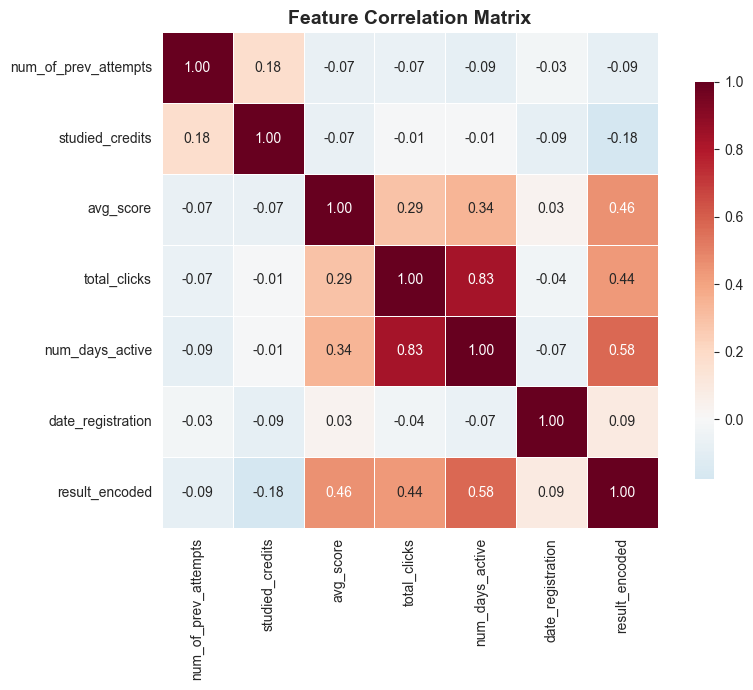

In [10]:
# Build a combined feature table per student-module for correlation analysis
# Average score per student: link assessments to modules, then join with student scores
sa_with_module = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation']],
    on='id_assessment', how='inner'
)
avg_score = sa_with_module.groupby(
    ['code_module', 'code_presentation', 'id_student']
)['score'].mean().reset_index()
avg_score.rename(columns={'score': 'avg_score'}, inplace=True)

# Combine features
combined = student_info[['code_module', 'code_presentation', 'id_student',
                         'num_of_prev_attempts', 'studied_credits', 'final_result']].copy()
combined = combined.merge(avg_score, on=['code_module', 'code_presentation', 'id_student'], how='left')
combined = combined.merge(vle_per_student, on=['code_module', 'code_presentation', 'id_student'], how='left')
combined = combined.merge(
    reg_with_result[['code_module', 'code_presentation', 'id_student', 'date_registration']],
    on=['code_module', 'code_presentation', 'id_student'], how='left'
)

# Encode final_result numerically for correlation
result_map = {'Distinction': 3, 'Pass': 2, 'Fail': 1, 'Withdrawn': 0}
combined['result_encoded'] = combined['final_result'].map(result_map)

# Correlation heatmap
numeric_cols = ['num_of_prev_attempts', 'studied_credits', 'avg_score',
                'total_clicks', 'num_days_active', 'date_registration', 'result_encoded']
corr = combined[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Summary

**Key findings:**
1. **Class imbalance** – "Withdrawn" and "Pass" are the largest groups; "Distinction" is smallest. For modeling, Distinction and Pass are combined into one class, and Fail and Withdrawn into another one (binary classification for dropout prediction).
2. **VLE engagement matters** – Students who pass/get distinction have significantly more VLE clicks and more active days than those who fail or withdraw.
3. **Assessment scores are predictive** – Average score strongly correlates with final outcome.
4. **Registration timing** – Students who register earlier (more negative `date_registration`) tend to perform better.
5. **Previous attempts** – Students with more prior attempts are slightly more likely to fail or withdraw.
6. **Demographics** – Education level has a visible effect on outcomes; age and gender show smaller differences.

## 2. Data Preprocessing

**Goal:** Build a single table (one row per student registration) ready for binary classification — an **early-warning dropout prediction** model.

- **Scope:** Single module & presentation (configurable), using only data available within the first N days
- **Target variable:** `dropout` — 1 = Fail/Withdrawn (positive class), 0 = Pass/Distinction
- **Data leakage prevention:** Students who unregistered before the cutoff day are excluded (their outcome is already known)
- **Steps:** configure filters → filter data → merge tables (with time cutoff) → encode → handle missing → scale

### 2.1 Configuration & Filtering

Change the parameters below to easily adjust the scope of the analysis.

Configuration: module=BBB, presentation=2013B, day_cutoff=30
Students in BBB/2013B: 1767
Students unregistered before day 30: 238 (excluded)

Remaining students: 1529
Target distribution:
dropout
0    803
1    726
Name: count, dtype: int64
Dropout rate: 47.5%


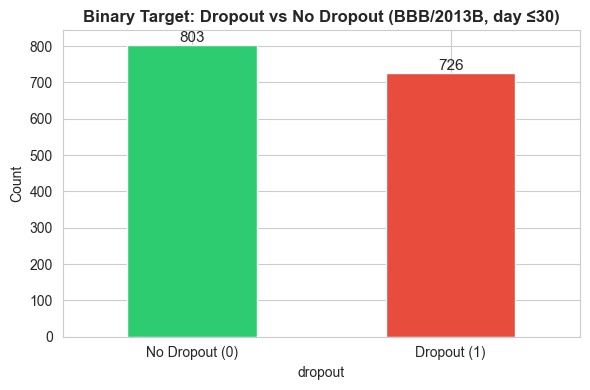

In [11]:
# ============================================================
# CONFIGURATION
# ============================================================
MODULE = 'BBB'           # code_module to filter on
PRESENTATION = '2013B'   # code_presentation to filter on
DAY_CUTOFF = 30          # only use data from day 0 to this day
# ============================================================

print(f"Configuration: module={MODULE}, presentation={PRESENTATION}, day_cutoff={DAY_CUTOFF}")

# Filter student_info to selected module & presentation
df = student_info[
    (student_info['code_module'] == MODULE) &
    (student_info['code_presentation'] == PRESENTATION)
].copy()
print(f"Students in {MODULE}/{PRESENTATION}: {len(df)}")

# Remove students who unregistered before the cutoff day (data leakage)
reg = student_registration[
    (student_registration['code_module'] == MODULE) &
    (student_registration['code_presentation'] == PRESENTATION)
].copy()

# Students who left before DAY_CUTOFF — their outcome is already known, exclude them
early_unreg = reg[reg['date_unregistration'].notna() & (reg['date_unregistration'] < DAY_CUTOFF)]
print(f"Students unregistered before day {DAY_CUTOFF}: {len(early_unreg)} (excluded)")
df = df[~df['id_student'].isin(early_unreg['id_student'])]

# Binary target: dropout = 1 (Fail, Withdrawn), no dropout = 0 (Pass, Distinction)
df['dropout'] = df['final_result'].apply(lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0)

print(f"\nRemaining students: {len(df)}")
print(f"Target distribution:\n{df['dropout'].value_counts()}")
print(f"Dropout rate: {df['dropout'].mean()*100:.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
df['dropout'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_xticklabels(['No Dropout (0)', 'Dropout (1)'], rotation=0)
ax.set_title(f'Binary Target: Dropout vs No Dropout ({MODULE}/{PRESENTATION}, day ≤{DAY_CUTOFF})',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### 2.2 Merge All Tables (with Day Cutoff)

Aggregate features using **only data from the first N days** to prevent data leakage.

In [12]:
merge_keys = ['code_module', 'code_presentation', 'id_student']

# 1. Registration features
reg_features = reg[['code_module', 'code_presentation', 'id_student', 'date_registration']].copy()
df = df.merge(reg_features, on=merge_keys, how='left')
print(f"After merging registration: {df.shape}")

# 2. Assessment features (only assessments submitted within first DAY_CUTOFF days)
sa = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type']],
    on='id_assessment', how='inner'
)
# Filter to selected module/presentation AND submissions within the cutoff
sa = sa[
    (sa['code_module'] == MODULE) &
    (sa['code_presentation'] == PRESENTATION) &
    (sa['date_submitted'] <= DAY_CUTOFF)
]

assessment_features = sa.groupby(merge_keys).agg(
    avg_score=('score', 'mean'),
    num_assessments_submitted=('id_assessment', 'count'),
    score_std=('score', 'std')
).reset_index()
assessment_features['score_std'] = assessment_features['score_std'].fillna(0)

df = df.merge(assessment_features, on=merge_keys, how='left')
print(f"After merging assessments (day ≤{DAY_CUTOFF}): {df.shape}")

# 3. VLE engagement features (only interactions within first DAY_CUTOFF days)
vle_filtered = student_vle[
    (student_vle['code_module'] == MODULE) &
    (student_vle['code_presentation'] == PRESENTATION) &
    (student_vle['date'] <= DAY_CUTOFF)
]

vle_features = vle_filtered.groupby(merge_keys).agg(
    total_clicks=('sum_click', 'sum'),
    num_days_active=('date', 'nunique'),
    num_vle_resources=('id_site', 'nunique'),
    avg_clicks_per_day=('sum_click', 'mean')
).reset_index()

df = df.merge(vle_features, on=merge_keys, how='left')
print(f"After merging VLE features (day ≤{DAY_CUTOFF}): {df.shape}")

# 4. Course length
df = df.merge(courses[['code_module', 'code_presentation', 'module_presentation_length']],
              on=['code_module', 'code_presentation'], how='left')
print(f"After merging course info: {df.shape}")

print(f"\nFinal merged table: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

After merging registration: (1529, 14)
After merging assessments (day ≤30): (1529, 17)
After merging VLE features (day ≤30): (1529, 21)
After merging course info: (1529, 22)

Final merged table: 1529 rows × 22 columns


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,dropout,date_registration,avg_score,num_assessments_submitted,score_std,total_clicks,num_days_active,num_vle_resources,avg_clicks_per_day,module_presentation_length
0,BBB,2013B,23629,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,...,1,-47.0,67.0,1.0,0.0,53.0,6.0,7.0,2.523810,240
1,BBB,2013B,25107,F,East Anglian Region,Lower Than A Level,20-30%,0-35,0,120,...,0,-73.0,59.0,1.0,0.0,85.0,8.0,12.0,2.833333,240
2,BBB,2013B,27891,M,Scotland,Lower Than A Level,0-10%,0-35,2,120,...,1,-58.0,73.0,1.0,0.0,187.0,9.0,18.0,3.065574,240
3,BBB,2013B,29144,M,South Region,Lower Than A Level,60-70%,0-35,0,120,...,1,-24.0,60.0,1.0,0.0,212.0,10.0,22.0,2.523810,240
4,BBB,2013B,31663,M,North Region,A Level or Equivalent,30-40%,35-55,0,60,...,0,-60.0,88.0,1.0,0.0,1193.0,39.0,55.0,3.286501,240


### 2.3 Handle Missing Values

In [13]:
# Check missing values
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal rows: {len(df)}")

# VLE features: students with no VLE activity → fill with 0 (they never interacted)
vle_cols = ['total_clicks', 'num_days_active', 'num_vle_resources', 'avg_clicks_per_day']
df[vle_cols] = df[vle_cols].fillna(0)

# Assessment features: students who submitted no assessments → fill with 0
assessment_cols = ['avg_score', 'num_assessments_submitted', 'score_std']
df[assessment_cols] = df[assessment_cols].fillna(0)

# imd_band: has some missing values — fill with the most frequent value (mode)
if df['imd_band'].isnull().sum() > 0:
    df['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0])
    print(f"\nimd_band missing filled with mode: '{df['imd_band'].mode()[0]}'")

# date_registration: fill missing with median
if df['date_registration'].isnull().sum() > 0:
    median_reg = df['date_registration'].median()
    df['date_registration'] = df['date_registration'].fillna(median_reg)
    print(f"date_registration missing filled with median: {median_reg}")

# Verify no missing values remain
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Missing values per column:
imd_band                      19
date_registration              1
avg_score                    213
num_assessments_submitted    212
score_std                    212
total_clicks                  82
num_days_active               82
num_vle_resources             82
avg_clicks_per_day            82
dtype: int64

Total rows: 1529

imd_band missing filled with mode: '20-30%'
date_registration missing filled with median: -50.0

Remaining missing values: 0


### 2.4 Encode Categorical Variables

Encode categorical features so they can be used by classification models. We use:
- **Label encoding** for ordinal features (`imd_band`, `age_band`, `highest_education`)
- **Binary encoding** for `gender`, `disability`
- **One-hot encoding** for `region`

In [14]:
# Ordinal encoding

# IMD band (Index of Multiple Deprivation) — ordered from low to high deprivation
imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
df['imd_band'] = df['imd_band'].map({v: i for i, v in enumerate(imd_order)})

# Age band — ordinal
age_order = {'0-35': 0, '35-55': 1, '55<=': 2}
df['age_band'] = df['age_band'].map(age_order)

# Highest education — ordinal (low to high)
edu_order = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df['highest_education'] = df['highest_education'].map(edu_order)

# One-hot / binary encoding for nominal features
# Gender: binary
df['gender'] = (df['gender'] == 'M').astype(int)  # 1 = Male, 0 = Female

# Disability: binary
df['disability'] = (df['disability'] == 'Y').astype(int)  # 1 = Yes, 0 = No

# Region — one-hot encode
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

# Drop columns not needed for modeling (single module/presentation, so no info there)
df.drop(columns=['final_result', 'code_module', 'code_presentation', 'id_student'], inplace=True)

# Save preprocessed dataset to data/ folder
dataset_filename = f'data/{MODULE}_{PRESENTATION}_day{DAY_CUTOFF}_preprocessed.csv'
df.to_csv(dataset_filename, index=False)
print(f"Preprocessed dataset saved to: {dataset_filename}")

print(f"\nDataset after encoding: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")
df.head()

Preprocessed dataset saved to: data/BBB_2013B_day30_preprocessed.csv

Dataset after encoding: 1529 rows × 29 columns

Column types:
int64      20
float64     9
Name: count, dtype: int64


,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,dropout,date_registration,avg_score,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,0,1,2.0,0,2,60,0,1,-47.0,67.0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,2.0,0,0,120,0,0,-73.0,59.0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0.0,0,2,120,1,1,-58.0,73.0,...,0,0,0,1,0,0,0,0,0,0
3,1,1,6.0,0,0,120,0,1,-24.0,60.0,...,0,0,0,0,0,1,0,0,0,0
4,1,2,3.0,1,0,60,0,0,-60.0,88.0,...,0,1,0,0,0,0,0,0,0,0


### 2.5 Feature Scaling & Final Dataset

In [15]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=['dropout'])
y = df['dropout']

# Final safety check: fill any remaining NaN values
if X.isnull().sum().sum() > 0:
    print(f"Remaining NaN values found ({X.isnull().sum().sum()} total):")
    print(X.isnull().sum()[X.isnull().sum() > 0])
    # Fill numeric NaN with median, categorical with mode (0 for encoded)
    X = X.fillna(X.median())
    print("Filled with column medians.\n")

# Identify numeric columns to scale (exclude binary/one-hot columns)
numeric_features = ['num_of_prev_attempts', 'studied_credits', 'date_registration',
                    'avg_score', 'num_assessments_submitted', 'score_std',
                    'total_clicks', 'num_days_active', 'num_vle_resources',
                    'avg_clicks_per_day', 'module_presentation_length']

# Keep only columns that actually exist in the dataframe
numeric_features = [c for c in numeric_features if c in X.columns]

scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

X.head()

Remaining NaN values found (189 total):
imd_band    189
dtype: int64
Filled with column medians.

Features (X): (1529, 28)
Target  (y): (1529,)

Target distribution:
dropout
0    803
1    726
Name: count, dtype: int64

Class balance: {0: 0.525, 1: 0.475}


,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,avg_score,num_assessments_submitted,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,0,1,2.0,0,3.020196,-0.661783,0,0.250388,0.199708,0.294224,...,0,0,0,0,0,0,0,0,0,0
1,0,1,2.0,0,-0.432424,0.806108,0,-0.402671,-0.093435,0.294224,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0.0,0,3.020196,0.806108,1,-0.025906,0.419565,0.294224,...,0,0,0,1,0,0,0,0,0,0
3,1,1,6.0,0,-0.432424,0.806108,0,0.828095,-0.056793,0.294224,...,0,0,0,0,0,1,0,0,0,0
4,1,2,3.0,1,-0.432424,-0.661783,0,-0.076142,0.969208,0.294224,...,0,1,0,0,0,0,0,0,0,0


In [16]:
# Final check: descriptive statistics of the preprocessed features
print("Preprocessed dataset summary:")
print(f"  Rows: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Missing values: {X.isnull().sum().sum()}")
print(f"  Dropout rate: {y.mean()*100:.1f}%")
print(f"\nFeature list ({X.shape[1]} features):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n{'='*50}")
print("Data is ready for classification models.")
print(f"{'='*50}")

Preprocessed dataset summary:
  Rows: 1529
  Features: 28
  Missing values: 0
  Dropout rate: 47.5%

Feature list (28 features):
   1. gender
   2. highest_education
   3. imd_band
   4. age_band
   5. num_of_prev_attempts
   6. studied_credits
   7. disability
   8. date_registration
   9. avg_score
  10. num_assessments_submitted
  11. score_std
  12. total_clicks
  13. num_days_active
  14. num_vle_resources
  15. avg_clicks_per_day
  16. module_presentation_length
  17. region_East Midlands Region
  18. region_Ireland
  19. region_London Region
  20. region_North Region
  21. region_North Western Region
  22. region_Scotland
  23. region_South East Region
  24. region_South Region
  25. region_South West Region
  26. region_Wales
  27. region_West Midlands Region
  28. region_Yorkshire Region

Data is ready for classification models.


## 3. Model Training — LR, DT, NN

Train three classifiers with **stratified 5-fold cross-validation** and **hyperparameter tuning** (GridSearchCV).

- **Logistic Regression (LR)** — linear baseline
- **Decision Tree (DT)** — interpretable non-linear model
- **Neural Network (NN)** — MLPClassifier

Each model is tuned on the training set; final evaluation on the held-out test set comes in Section 4.

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Train/test split (80/20, stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain dropout rate: {y_train.mean()*100:.1f}%")
print(f"Test  dropout rate: {y_test.mean()*100:.1f}%")

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results for comparison
results = {}

Training set: 1223 samples
Test set:     306 samples

Train dropout rate: 47.5%
Test  dropout rate: 47.4%


### 3.1 Logistic Regression

In [18]:
# Logistic Regression — hyperparameter tuning with GridSearchCV
# class_weight: higher cost for missing a dropout (class 1)
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight={0: 1, 1: 2}),
    param_grid=lr_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)
lr_grid.fit(X_train, y_train)

print("Logistic Regression — GridSearchCV Results")
print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best CV AUC: {lr_grid.best_score_:.4f}")

lr_cv_results = pd.DataFrame(lr_grid.cv_results_).sort_values('rank_test_score')
print(f"\nTop 5 parameter combinations:")
print(lr_cv_results[['params', 'mean_test_score', 'std_test_score',
                      'mean_train_score']].head().to_string(index=False))

lr_best = lr_grid.best_estimator_
results['Logistic Regression'] = {
    'model': lr_best,
    'best_params': lr_grid.best_params_,
    'cv_auc': lr_grid.best_score_
}

Logistic Regression — GridSearchCV Results
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC: 0.8017

Top 5 parameter combinations:
                                            params  mean_test_score  std_test_score  mean_train_score
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}         0.801726        0.021472          0.822019
  {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}         0.799959        0.025665          0.822979
  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}         0.799492        0.026309          0.823086
 {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}         0.798700        0.027082          0.822957
{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}         0.798593        0.027092          0.822936


### 3.2 Decision Tree

In [19]:
# Decision Tree — hyperparameter tuning with GridSearchCV
# class_weight: higher cost for missing a dropout (class 1)
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight={0: 1, 1: 2}),
    param_grid=dt_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)
dt_grid.fit(X_train, y_train)

print("Decision Tree — GridSearchCV Results")
print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best CV AUC: {dt_grid.best_score_:.4f}")

dt_cv_results = pd.DataFrame(dt_grid.cv_results_).sort_values('rank_test_score')
print(f"\nTop 5 parameter combinations:")
print(dt_cv_results[['params', 'mean_test_score', 'std_test_score',
                      'mean_train_score']].head().to_string(index=False))

dt_best = dt_grid.best_estimator_
results['Decision Tree'] = {
    'model': dt_best,
    'best_params': dt_grid.best_params_,
    'cv_auc': dt_grid.best_score_
}

Decision Tree — GridSearchCV Results
Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best CV AUC: 0.7430

Top 5 parameter combinations:
                                                                                   params  mean_test_score  std_test_score  mean_train_score
 {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 20}         0.742956        0.027237          0.872248
 {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}         0.741202        0.024890          0.863668
 {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 5}         0.741202        0.024890          0.863668
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 10}         0.741202        0.024890          0.863668
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 20}         0.7

### 3.3 Neural Network (MLPClassifier)

In [20]:
# Neural Network (MLP) — hyperparameter tuning with GridSearchCV
# Note: MLPClassifier does not support class_weight, but AUC scoring
# still rewards ranking dropout students higher
nn_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

nn_grid = GridSearchCV(
    MLPClassifier(random_state=42, max_iter=1000, early_stopping=True,
                  validation_fraction=0.15),
    param_grid=nn_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)
nn_grid.fit(X_train, y_train)

print("Neural Network (MLP) — GridSearchCV Results")
print(f"Best parameters: {nn_grid.best_params_}")
print(f"Best CV AUC: {nn_grid.best_score_:.4f}")

nn_cv_results = pd.DataFrame(nn_grid.cv_results_).sort_values('rank_test_score')
print(f"\nTop 5 parameter combinations:")
print(nn_cv_results[['params', 'mean_test_score', 'std_test_score',
                      'mean_train_score']].head().to_string(index=False))

nn_best = nn_grid.best_estimator_
results['Neural Network'] = {
    'model': nn_best,
    'best_params': nn_grid.best_params_,
    'cv_auc': nn_grid.best_score_
}

Neural Network (MLP) — GridSearchCV Results
Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant'}
Best CV AUC: 0.7955

Top 5 parameter combinations:
                                                                                               params  mean_test_score  std_test_score  mean_train_score
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant'}         0.795525        0.032624          0.840504
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'adaptive'}         0.795525        0.032624          0.840504
 {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'adaptive'}         0.791260        0.031162          0.833573
 {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant'}         0.791260        0.031162          0.833573
{'activation': 'tanh'

## 4. Model Performance Comparison

  MODEL PERFORMANCE — Test Set Evaluation

Logistic Regression:
  CV AUC:       0.8017
  Test AUC:     0.8068
  Test Accuracy: 0.6830
  Test Precision: 0.6263
  Test Recall:   0.8207  (dropout detection rate)
  Test F1:       0.7104
  Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

Decision Tree:
  CV AUC:       0.7430
  Test AUC:     0.7301
  Test Accuracy: 0.6373
  Test Precision: 0.5904
  Test Recall:   0.7655  (dropout detection rate)
  Test F1:       0.6667
  Params: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 20}

Neural Network:
  CV AUC:       0.7955
  Test AUC:     0.7910
  Test Accuracy: 0.7092
  Test Precision: 0.7000
  Test Recall:   0.6759  (dropout detection rate)
  Test F1:       0.6877
  Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant'}

              Model   CV AUC  Test AUC  Accuracy  Precision   Recall       F1
Logistic Regression 0.801726  0.806768  0.683

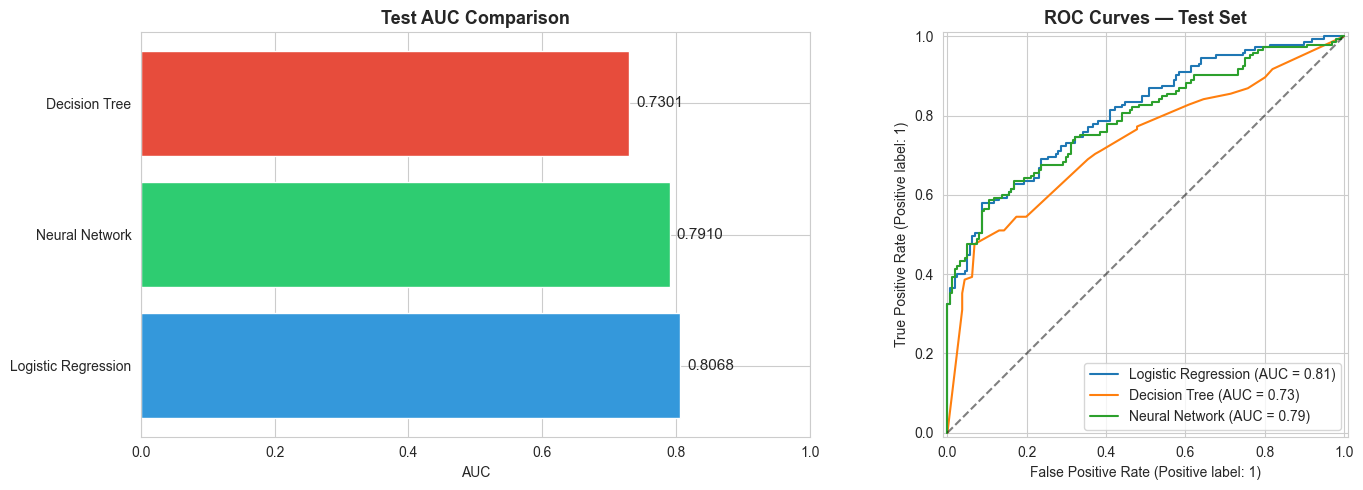

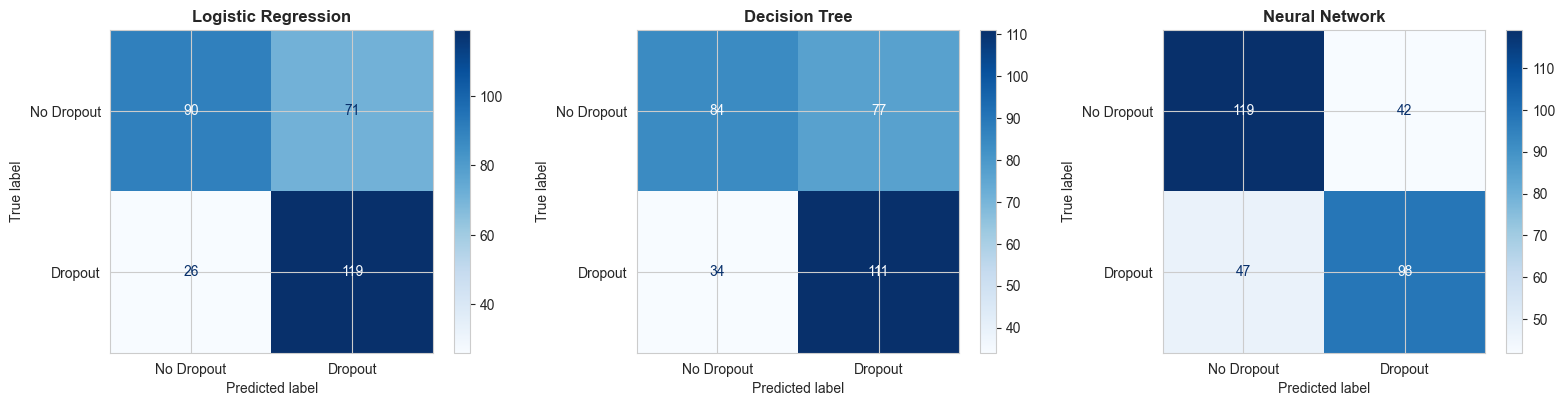

In [21]:
from sklearn.metrics import RocCurveDisplay

# Evaluate all models on the TEST set
print("=" * 70)
print("  MODEL PERFORMANCE — Test Set Evaluation")
print("=" * 70)

import joblib

comparison_data = []
for name, res in results.items():
    model = res['model']
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{name}:")
    print(f"  CV AUC:       {res['cv_auc']:.4f}")
    print(f"  Test AUC:     {auc:.4f}")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Test Precision: {prec:.4f}")
    print(f"  Test Recall:   {rec:.4f}  (dropout detection rate)")
    print(f"  Test F1:       {f1:.4f}")
    print(f"  Params: {res['best_params']}")

    comparison_data.append({
        'Model': name, 'CV AUC': res['cv_auc'],
        'Test AUC': auc, 'Accuracy': acc,
        'Precision': prec, 'Recall': rec, 'F1': f1
    })

print("\n" + "=" * 70)

# Summary table
comparison_df = pd.DataFrame(comparison_data).sort_values('Test AUC', ascending=False)
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\nBest model: {best_model_name} (Test AUC = {comparison_df.iloc[0]['Test AUC']:.4f})")

# Save the best model
model_filename = f'models/best_model_{MODULE}_{PRESENTATION}_day{DAY_CUTOFF}.joblib'
joblib.dump(best_model, model_filename)
print(f"Best model saved to: {model_filename}")

# Also save the scaler for use on new data
scaler_filename = f'models/scaler_{MODULE}_{PRESENTATION}_day{DAY_CUTOFF}.joblib'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to: {scaler_filename}")

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# AUC comparison
colors_models = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0].barh(comparison_df['Model'], comparison_df['Test AUC'],
                    color=colors_models[:len(comparison_df)])
axes[0].set_xlabel('AUC')
axes[0].set_title('Test AUC Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1)
for bar in bars:
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.4f}', va='center', fontsize=11)

# ROC curves
for name, res in results.items():
    RocCurveDisplay.from_estimator(res['model'], X_test, y_test, ax=axes[1], name=name)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curves — Test Set', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    y_pred = res['model'].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['No Dropout', 'Dropout'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Applying the Best Model on New Data

We apply the best model (trained on **BBB / 2013B**) to a **new presentation** — **BBB / 2014B** — to evaluate how well the model generalises to unseen cohorts. The preprocessing pipeline mirrors Section 2, using the same feature engineering and the saved scaler.

### 5.1  Preprocess new data

In [22]:
# (BBB / 2014B, same DAY_CUTOFF)
NEW_PRESENTATION = '2014B'

print(f"Preprocessing new data: {MODULE}/{NEW_PRESENTATION}, day ≤ {DAY_CUTOFF}")

# Filter students
df_new = student_info[
    (student_info['code_module'] == MODULE) &
    (student_info['code_presentation'] == NEW_PRESENTATION)
].copy()
print(f"Students in {MODULE}/{NEW_PRESENTATION}: {len(df_new)}")

# Remove early un-registrations
reg_new = student_registration[
    (student_registration['code_module'] == MODULE) &
    (student_registration['code_presentation'] == NEW_PRESENTATION)
].copy()

early_unreg_new = reg_new[
    reg_new['date_unregistration'].notna() &
    (reg_new['date_unregistration'] < DAY_CUTOFF)
]
print(f"Students unregistered before day {DAY_CUTOFF}: {len(early_unreg_new)} (excluded)")
df_new = df_new[~df_new['id_student'].isin(early_unreg_new['id_student'])]

# Binary target
df_new['dropout'] = df_new['final_result'].apply(
    lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0
)
print(f"Remaining students: {len(df_new)}")
print(f"Dropout rate: {df_new['dropout'].mean()*100:.1f}%")

# Merge keys
mk = ['code_module', 'code_presentation', 'id_student']

# 1. Registration features
reg_feat_new = reg_new[['code_module', 'code_presentation', 'id_student', 'date_registration']].copy()
df_new = df_new.merge(reg_feat_new, on=mk, how='left')

# 2. Assessment features (day ≤ cutoff)
sa_new = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type']],
    on='id_assessment', how='inner'
)
sa_new = sa_new[
    (sa_new['code_module'] == MODULE) &
    (sa_new['code_presentation'] == NEW_PRESENTATION) &
    (sa_new['date_submitted'] <= DAY_CUTOFF)
]
asmt_feat_new = sa_new.groupby(mk).agg(
    avg_score=('score', 'mean'),
    num_assessments_submitted=('id_assessment', 'count'),
    score_std=('score', 'std')
).reset_index()
asmt_feat_new['score_std'] = asmt_feat_new['score_std'].fillna(0)
df_new = df_new.merge(asmt_feat_new, on=mk, how='left')

# 3. VLE engagement features (day ≤ cutoff)
vle_new = student_vle[
    (student_vle['code_module'] == MODULE) &
    (student_vle['code_presentation'] == NEW_PRESENTATION) &
    (student_vle['date'] <= DAY_CUTOFF)
]
vle_feat_new = vle_new.groupby(mk).agg(
    total_clicks=('sum_click', 'sum'),
    num_days_active=('date', 'nunique'),
    num_vle_resources=('id_site', 'nunique'),
    avg_clicks_per_day=('sum_click', 'mean')
).reset_index()
df_new = df_new.merge(vle_feat_new, on=mk, how='left')

# 4. Course length
df_new = df_new.merge(
    courses[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'], how='left'
)

# Handle missing
vle_cols_new = ['total_clicks', 'num_days_active', 'num_vle_resources', 'avg_clicks_per_day']
df_new[vle_cols_new] = df_new[vle_cols_new].fillna(0)

asmt_cols_new = ['avg_score', 'num_assessments_submitted', 'score_std']
df_new[asmt_cols_new] = df_new[asmt_cols_new].fillna(0)

if df_new['imd_band'].isnull().sum() > 0:
    df_new['imd_band'] = df_new['imd_band'].fillna(df_new['imd_band'].mode()[0])

if df_new['date_registration'].isnull().sum() > 0:
    df_new['date_registration'] = df_new['date_registration'].fillna(df_new['date_registration'].median())

# Encode (same mappings as training)
df_new['imd_band'] = df_new['imd_band'].map({v: i for i, v in enumerate(imd_order)})
df_new['age_band'] = df_new['age_band'].map(age_order)
df_new['highest_education'] = df_new['highest_education'].map(edu_order)
df_new['gender'] = (df_new['gender'] == 'M').astype(int)
df_new['disability'] = (df_new['disability'] == 'Y').astype(int)
df_new = pd.get_dummies(df_new, columns=['region'], drop_first=True, dtype=int)

y_new = df_new['dropout']
df_new.drop(columns=['final_result', 'code_module', 'code_presentation', 'id_student', 'dropout'], inplace=True)

# Align columns with training set (add missing dummies as 0, drop extra ones)
train_cols = X.columns.tolist()
for col in train_cols:
    if col not in df_new.columns:
        df_new[col] = 0
df_new = df_new[train_cols]

# Safety NaN fill
df_new = df_new.fillna(df_new.median())

# Scale numeric features with the SAME scaler used in training
df_new[numeric_features] = scaler.transform(df_new[numeric_features])

X_new = df_new

# Save preprocessed new dataset
new_dataset_filename = f'data/{MODULE}_{NEW_PRESENTATION}_day{DAY_CUTOFF}_preprocessed.csv'
X_new.to_csv(new_dataset_filename, index=False)
print(f"Preprocessed new dataset saved to: {new_dataset_filename}")

print(f"\nNew dataset ready: {X_new.shape[0]} rows × {X_new.shape[1]} columns")
print(f"Target: {y_new.value_counts().to_dict()}")

Preprocessing new data: BBB/2014B, day ≤ 30
Students in BBB/2014B: 1613
Students unregistered before day 30: 331 (excluded)
Remaining students: 1282
Dropout rate: 43.3%
Preprocessed new dataset saved to: data/BBB_2014B_day30_preprocessed.csv

New dataset ready: 1282 rows × 28 columns
Target: {0: 727, 1: 555}


### 5.2  Apply saved model & evaluate on new data

Loaded model: LogisticRegression
Trained on: BBB/2013B, day ≤ 30
Applying to: BBB/2014B, day ≤ 30

  Results on BBB/2014B
  AUC:       0.7529
  Accuracy:  0.6154
  Precision: 0.5360
  Recall:    0.8324  (dropout detection rate)
  F1:        0.6521

Classification Report:

              precision    recall  f1-score   support

  No Dropout       0.78      0.45      0.57       727
     Dropout       0.54      0.83      0.65       555

    accuracy                           0.62      1282
   macro avg       0.66      0.64      0.61      1282
weighted avg       0.67      0.62      0.61      1282



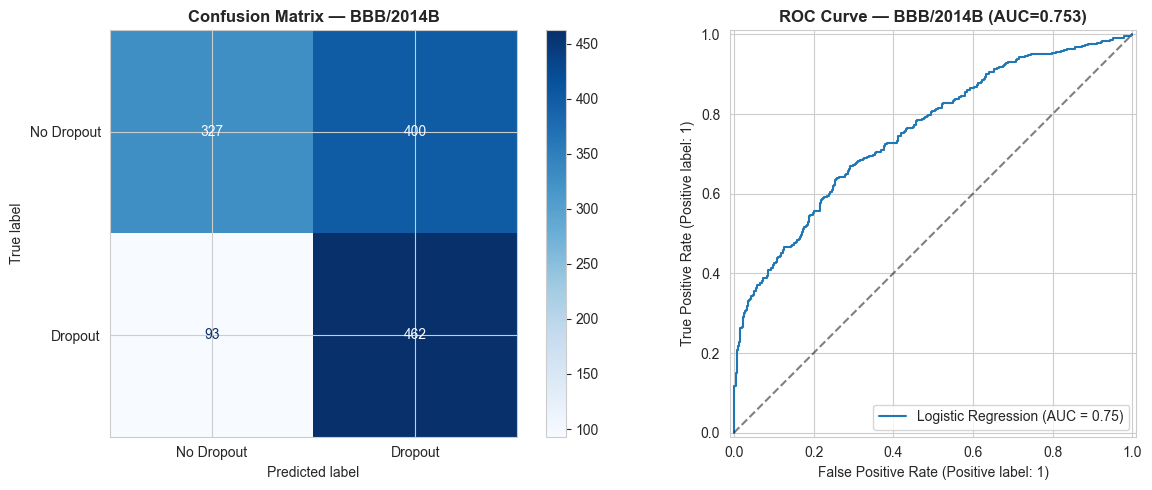


Generalisation Summary:
  Train data (2013B) Test AUC:  0.8068
  New data   (2014B) AUC:     0.7529
  AUC drop: 0.0538 (notable)


In [23]:
import joblib

# Load saved model and scaler (demonstrates full portability)
loaded_model = joblib.load(f'models/best_model_{MODULE}_{PRESENTATION}_day{DAY_CUTOFF}.joblib')
print(f"Loaded model: {type(loaded_model).__name__}")
print(f"Trained on: {MODULE}/{PRESENTATION}, day ≤ {DAY_CUTOFF}")
print(f"Applying to: {MODULE}/{NEW_PRESENTATION}, day ≤ {DAY_CUTOFF}")

# Predictions
y_new_pred = loaded_model.predict(X_new)
y_new_proba = loaded_model.predict_proba(X_new)[:, 1]

# Metrics
from sklearn.metrics import classification_report

acc_new = accuracy_score(y_new, y_new_pred)
prec_new = precision_score(y_new, y_new_pred)
rec_new = recall_score(y_new, y_new_pred)
f1_new = f1_score(y_new, y_new_pred)
auc_new = roc_auc_score(y_new, y_new_proba)

print(f"\n{'='*60}")
print(f"  Results on {MODULE}/{NEW_PRESENTATION}")
print(f"{'='*60}")
print(f"  AUC:       {auc_new:.4f}")
print(f"  Accuracy:  {acc_new:.4f}")
print(f"  Precision: {prec_new:.4f}")
print(f"  Recall:    {rec_new:.4f}  (dropout detection rate)")
print(f"  F1:        {f1_new:.4f}")
print(f"{'='*60}")

print(f"\nClassification Report:\n")
print(classification_report(y_new, y_new_pred, target_names=['No Dropout', 'Dropout']))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_new, y_new_pred, display_labels=['No Dropout', 'Dropout'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — {MODULE}/{NEW_PRESENTATION}',
                  fontsize=12, fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_new, y_new_proba, ax=axes[1],
                                  name=f'{best_model_name}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title(f'ROC Curve — {MODULE}/{NEW_PRESENTATION} (AUC={auc_new:.3f})',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Compare training vs new data performance
print(f"\nGeneralisation Summary:")
print(f"  Train data ({PRESENTATION}) Test AUC:  {comparison_df.iloc[0]['Test AUC']:.4f}")
print(f"  New data   ({NEW_PRESENTATION}) AUC:     {auc_new:.4f}")
auc_diff = comparison_df.iloc[0]['Test AUC'] - auc_new
print(f"  AUC drop: {auc_diff:.4f} ({'acceptable' if abs(auc_diff) < 0.05 else 'notable'})")

## 6. Clustering — K-Means

We use **K-Means clustering** on the training data to discover natural student groups based on their engagement and demographic features. This unsupervised analysis can reveal distinct behavioural patterns that complement the supervised dropout prediction.

### 6.1  Determine optimal K  (Elbow + Silhouette)

K= 2  |  Inertia=17,110  |  Silhouette=0.2262
K= 3  |  Inertia=15,231  |  Silhouette=0.2244
K= 4  |  Inertia=13,596  |  Silhouette=0.2306
K= 5  |  Inertia=12,258  |  Silhouette=0.1799
K= 6  |  Inertia=11,174  |  Silhouette=0.1822
K= 7  |  Inertia=10,668  |  Silhouette=0.1613
K= 8  |  Inertia=10,185  |  Silhouette=0.1770
K= 9  |  Inertia=9,769  |  Silhouette=0.1572
K=10  |  Inertia=9,409  |  Silhouette=0.1359


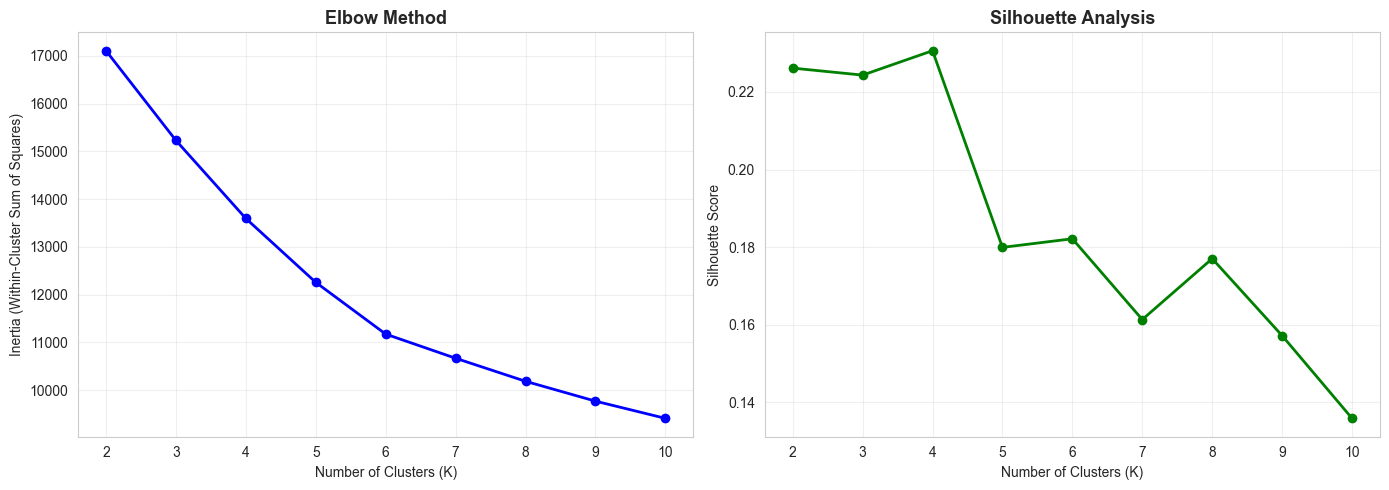


Best K by silhouette score: 4 (score = 0.2306)


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use training features (already scaled) for clustering
X_cluster = X_train.copy()

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))
    print(f"K={k:2d}  |  Inertia={km.inertia_:,.0f}  |  Silhouette={silhouettes[-1]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = K_range[0] + silhouettes.index(max(silhouettes))
print(f"\nBest K by silhouette score: {best_k} (score = {max(silhouettes):.4f})")

### 6.2  Fit K-Means with optimal K & analyse clusters

In [25]:
BEST_K = best_k  # from silhouette analysis above
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10, max_iter=300)
cluster_labels = km_final.fit_predict(X_cluster)

print(f"K-Means with K={BEST_K}")
print(f"Cluster sizes:")
for c in range(BEST_K):
    n = (cluster_labels == c).sum()
    print(f"  Cluster {c}: {n} students ({n/len(cluster_labels)*100:.1f}%)")

# Cluster profiles: mean feature values per cluster
cluster_df = X_train.copy()
cluster_df['cluster'] = cluster_labels
cluster_df['dropout'] = y_train.values

# Profile table — mean of each feature per cluster
profile = cluster_df.groupby('cluster').mean()
print(f"\nCluster Profiles (mean feature values, scaled):")
print(profile.round(3).to_string())

# Dropout rate per cluster
dropout_by_cluster = cluster_df.groupby('cluster')['dropout'].mean()
print(f"\nDropout rate per cluster:")
for c, rate in dropout_by_cluster.items():
    print(f"  Cluster {c}: {rate*100:.1f}%")

K-Means with K=4
Cluster sizes:
  Cluster 0: 431 students (35.2%)
  Cluster 1: 638 students (52.2%)
  Cluster 2: 7 students (0.6%)
  Cluster 3: 147 students (12.0%)

Cluster Profiles (mean feature values, scaled):
         gender  highest_education  imd_band  age_band  num_of_prev_attempts  studied_credits  disability  date_registration  avg_score  num_assessments_submitted  score_std  total_clicks  num_days_active  num_vle_resources  avg_clicks_per_day  module_presentation_length  region_East Midlands Region  region_Ireland  region_London Region  region_North Region  region_North Western Region  region_Scotland  region_South East Region  region_South Region  region_South West Region  region_Wales  region_West Midlands Region  region_Yorkshire Region  dropout
cluster                                                                                                                                                                                                                               

### 6.3  Cluster visualisation

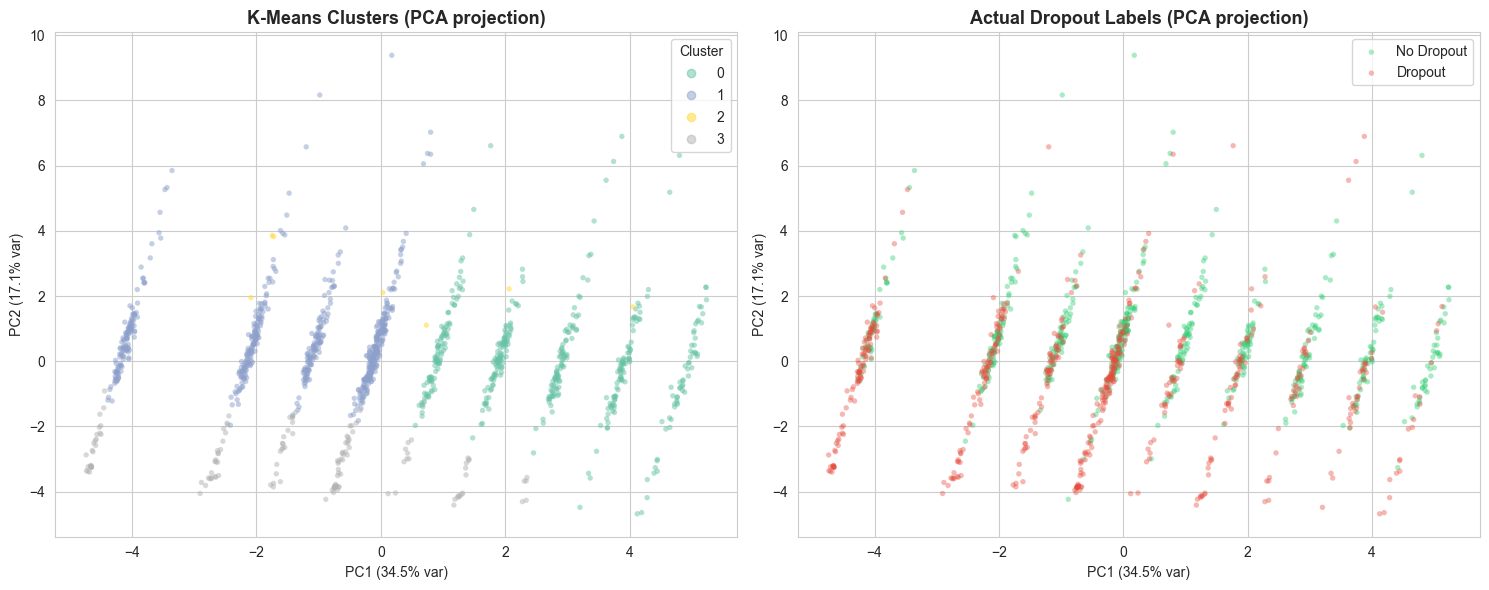

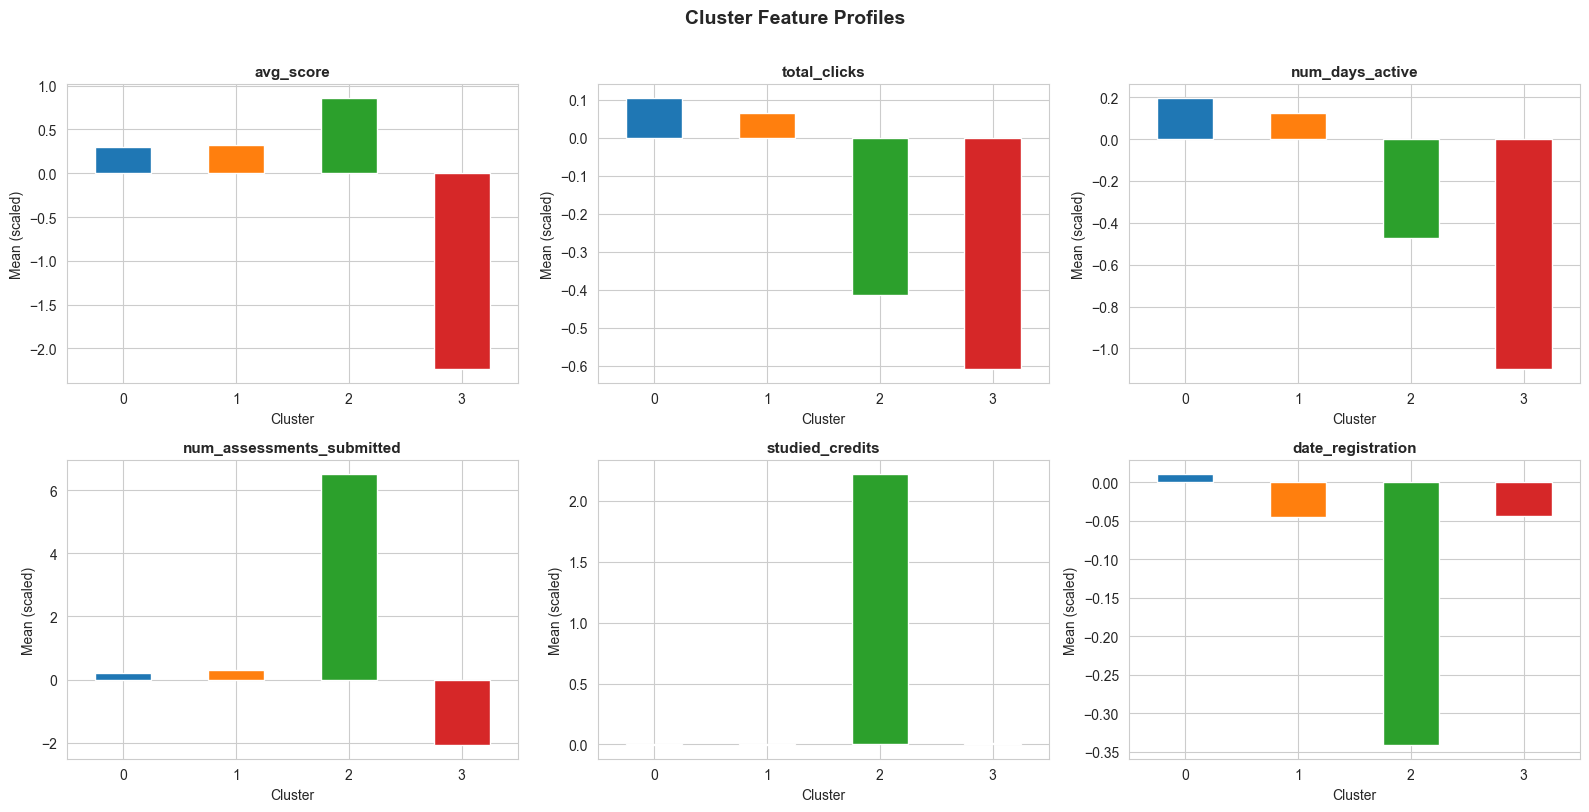

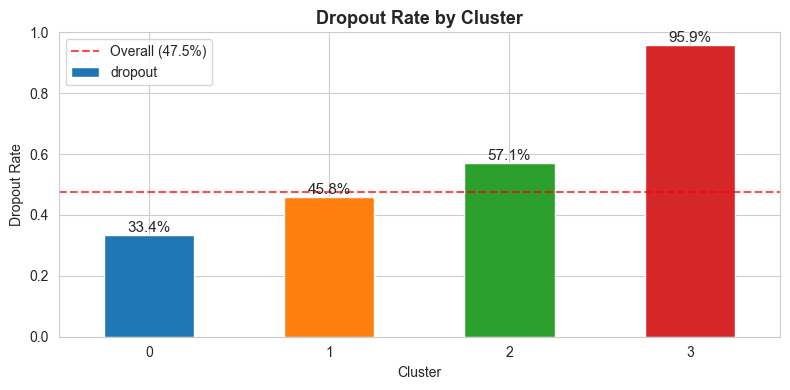

In [26]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Clusters in PCA space
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                          cmap='Set2', alpha=0.5, s=15, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('K-Means Clusters (PCA projection)', fontsize=13, fontweight='bold')
axes[0].legend(*scatter.legend_elements(), title='Cluster', loc='best')

# (b) Clusters colored by actual dropout
colors_dropout = ['#2ecc71', '#e74c3c']
for label, color, name in [(0, colors_dropout[0], 'No Dropout'),
                            (1, colors_dropout[1], 'Dropout')]:
    mask = y_train.values == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.4,
                    s=15, label=name, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('Actual Dropout Labels (PCA projection)', fontsize=13, fontweight='bold')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

# Key features per cluster (bar chart of selected features)
key_features = ['avg_score', 'total_clicks', 'num_days_active',
                'num_assessments_submitted', 'studied_credits', 'date_registration']
key_features = [f for f in key_features if f in profile.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    profile[feat].plot(kind='bar', ax=axes[i], color=[f'C{c}' for c in range(BEST_K)])
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Mean (scaled)')
    axes[i].tick_params(axis='x', rotation=0)

# Hide unused axes
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cluster Feature Profiles', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Dropout rate bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = dropout_by_cluster.plot(kind='bar', ax=ax, color=[f'C{c}' for c in range(BEST_K)])
ax.set_title('Dropout Rate by Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Dropout Rate')
ax.set_ylim(0, 1)
ax.axhline(y=y_train.mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall ({y_train.mean()*100:.1f}%)')
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 7. Conclusion

### Key Findings

**Supervised Learning (Sections 3–5):**
- **Logistic Regression** emerged as the best model with a test AUC of **0.807** on 2013B data, outperforming Decision Tree (0.730) and Neural Network (0.791).
- Using only the **first 30 days** of data, the model can detect ~82% of eventual dropouts (recall), making it viable as an early warning system.
- The class-weighted approach (`class_weight = {0: 1, 1: 2}`) successfully prioritised dropout detection over overall accuracy.
- When applied to **2014B data**, the model achieved AUC = 0.753 — a modest generalisation drop, suggesting the learned patterns are reasonably stable across cohorts.

**Unsupervised Learning (Section 6):**
- K-Means clustering (K=4) revealed distinct student profiles:
  - **Cluster 3** (~12% of students, **95.9% dropout**) — students with very low engagement: no assessments submitted, minimal VLE activity. These are the "ghost students" who registered but never engaged.
  - **Cluster 0** (~35%, **33.4% dropout**) — high-engagement students with above-average scores and VLE activity.
  - **Cluster 1** (~52%, **45.8% dropout**) — the largest group, with moderate engagement.
- Clusters align well with dropout risk, suggesting that engagement features (clicks, days active, submissions) are the dominant signals.

### Artifacts Saved
| Artifact | Path |
|----------|------|
| Preprocessed training dataset | `data/BBB_2013B_day30_preprocessed.csv` |
| Preprocessed new dataset | `data/BBB_2014B_day30_preprocessed.csv` |
| Best model | `models/best_model_BBB_2013B_day30.joblib` |
| Scaler | `models/scaler_BBB_2013B_day30.joblib` |

### Configuration
All filters can be changed via the variables at the top of Section 2:
- `MODULE`, `PRESENTATION`, `DAY_CUTOFF`